<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>On data</h1>
<h2>Unbalanced data</h2>
<p>Unbalanced data refers to when certain types of input data are overrepresented. Example: We want a model to distinguish cat pictures from boat pictures. We give it 99 pics of cats and 1 picture of a boat. Or: Most credit card transactions are not fraud.<br>What can we do about it? There are different solutions with different trade-offs.<ul>
<li>Get more data. Not always possible, but the best solution.</li>
<li>Undersampling: Throw out data until it is balanced. This might hurt generalizability</li>
<li>Oversampling: Create copies of rare data. Increases risk of overfitting.</li>
<li>Data augmentation: Add new features as nonlinear combinations of existing data. Usually feasible for images.</li>
<li>Create synthetic samples: Create fake but real-like data.</li>
</ul></p>
<h2>Saving and loading trained models</h2>
<p>Saving a trained model to file: torch.save(model.state_dict(), 'fileName.pt')<br>Loading: model.load_state_dict(torch.load('fileName.pt'))</p>
</div>

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Measuring model performance</h1>

<p>If we compare the reality to the model's output we have four different cases. For example, a model has to say whether the picture contains a cat or a boat.

<table>
<tr><td style="border: none;"></td><td colspan="3" style="text-align: center;">Reality</td></tr>
<tr>
<td rowspan="3" style="transform: rotate(-90deg);">Prediction</td>
<td></td>
<td>Cat</td>
<td>Boat</td>
</tr>
<tr>
<td>Cat</td>
<td>Hit</td>
<td>False alarm</td>
</tr>
<tr>
<td>Boat</td>
<td>Miss</td>
<td>Hit</td>
</tr>
</table>

Or with scientific terminology:

<table>
<tr><td style="border: none;"></td><td colspan="3" style="text-align: center;">Objective</td></tr>
<tr>
<td rowspan="3" style="transform: rotate(-90deg);">Subjective</td>
<td></td>
<td>Present</td>
<td>Absent</td>
</tr>
<tr>
<td>Yes</td>
<td>True positive</td>
<td>False positive</td>
</tr>
<tr>
<td>No</td>
<td>False negative</td>
<td>True negative</td>
</tr>
</table>

</p>

<p>Using these categories we can finetune how we view model accuracy.

$$ accuracy = \frac{True\,positive + True\,negative}{Number\,of\,samples} $$

$$ precision = \frac{True\,positive}{Number\,of\,yes\,predictions\,(True\,positives+False\,positives)} $$

$$ recall = \frac{True\,positive}{Number\,of\,present} $$

Precision can be helpful in discovering biases towards saying yes. Recall is helpful in discovering biases towards saying no. Recall is also called sensitivity. Combining precision and sensitivity into a single measure is the F1 score:

$$ F1 = \frac{True\,positive}{TP+(FP+FN)/2} $$

</p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
N = 50
numExps = 10_000

accuracy = np.zeros(numExps)
precision = np.zeros(numExps)
recall = np.zeros(numExps)
f1 = np.zeros(numExps)

for i in range(numExps):
    TP = np.random.randint(1, N)
    FN = N - TP
    TN = np.random.randint(1, N)
    FP = N - TN

    accuracy[i] = (TP + TN) / (2*N)
    precision[i] = TP / (TP + FP)
    recall[i] = TP / (TP + FN)
    f1[i] = TP / (TP + (FP + FN)/2)

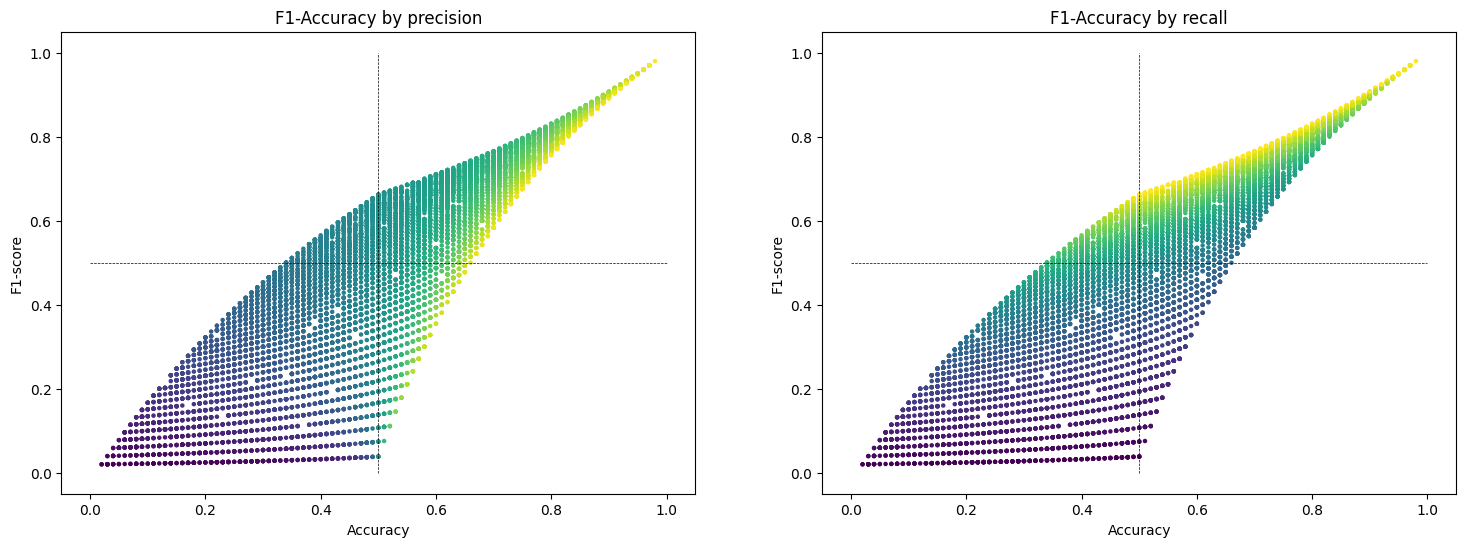

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].scatter(accuracy, f1, s=5, c=precision)
ax[0].plot([0, 1], [.5, .5], 'k--', linewidth=.5)
ax[0].plot([.5, .5], [0, 1], 'k--', linewidth=.5)
ax[0].set_xlabel('Accuracy')
ax[0].set_ylabel('F1-score')
ax[0].set_title('F1-Accuracy by precision')

ax[1].scatter(accuracy, f1, s=5, c=recall)
ax[1].plot([0, 1], [.5, .5], 'k--', linewidth=.5)
ax[1].plot([.5, .5], [0, 1], 'k--', linewidth=.5)
ax[1].set_xlabel('Accuracy')
ax[1].set_ylabel('F1-score')
ax[1].set_title('F1-Accuracy by recall')

plt.show()